# ***`Разработка и исследование архитектуры Transformer для задачи русско-английского машинного перевода`***
---

### Установка необходимых библиотек
---


In [ ]:
!pip install datasets

### Скачивание en-ru пары датасета opus-100
---

In [ ]:
from datasets import load_dataset

dataset = load_dataset("Helsinki-NLP/opus-100", "en-ru")

README.md:   0%|          | 0.00/65.4k [00:00<?, ?B/s]

en-ru/test-00000-of-00001.parquet:   0%|          | 0.00/310k [00:00<?, ?B/s]

en-ru/train-00000-of-00001.parquet:   0%|          | 0.00/124M [00:00<?, ?B/s]

en-ru/validation-00000-of-00001.parquet:   0%|          | 0.00/310k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/1000000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]


### Смотрю на структуру
---

In [ ]:
print(dataset)

DatasetDict({
    test: Dataset({
        features: ['translation'],
        num_rows: 2000
    })
    train: Dataset({
        features: ['translation'],
        num_rows: 1000000
    })
    validation: Dataset({
        features: ['translation'],
        num_rows: 2000
    })
})



### Пример
---

In [ ]:
print(dataset['train'][:2])

{'translation': [{'en': "Yeah, that's not exactly...", 'ru': 'Да, но не совсем...'}, {'en': '!', 'ru': '!'}]}


# Токенизация
---

In [ ]:
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace


tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
tokenizer.pre_tokenizer = Whitespace() # нарезаем по пробелам

In [ ]:
trainer = BpeTrainer(
    special_tokens=["[PAD]", "[UNK]", "[BOS]", "[EOS]"], # [PAD] - это пустышки, использую для выравнивания
    vocab_size=32000 # это базовый размер, который использовали авторы статьи "Attention is all you need" для англо-французского перевода
)

я обнаружила, что в датасете есть артефакты в виде китайских иероглифов и индийского алфавита, поэтому делаем проверку, чтобы оставить только латиницу и киррилицу

In [ ]:
import re


allowed_chars = re.compile(r"^[A-Za-zА-Яа-яЁё0-9\s.,!?;:()'\-\"«»—]*$")

def is_clean(text):
    return bool(allowed_chars.match(text))

нарезаю на батчи

In [ ]:
def batch_iterator(batch_size=1000):
    for i in range(0, len(dataset["train"]), batch_size):
        batch = dataset["train"][i : i + batch_size]
        text_batch = []
        for item in batch["translation"]:
            if is_clean(item["en"]) and is_clean(item["ru"]):
                text_batch.append(item["en"])
                text_batch.append(item["ru"])
        yield text_batch

обучаю токенизатор

In [ ]:
tokenizer.train_from_iterator(batch_iterator(), trainer)

сохраняю и смотрю, что там

In [ ]:
# tokenizer.save("opus100_bpe_tokenizer.json")

# Подготовка числовых данных для модели
---

In [ ]:
# ID специальных токенов из токенизатора
pad_id = tokenizer.token_to_id("[PAD]")
bos_id = tokenizer.token_to_id("[BOS]")
eos_id = tokenizer.token_to_id("[EOS]")

MAX_LENGTH = 200

def preprocess_function(examples):
    input_ids = []
    labels = []

    for item in examples["translation"]:
        # Токенизируем тексты и обрезаем их
        ru_encoded = tokenizer.encode(item["ru"]).ids[:MAX_LENGTH]
        en_encoded = tokenizer.encode(item["en"]).ids[:MAX_LENGTH]

        # Вход энкодера (русский)
        ru_sequence = ru_encoded + [eos_id] # текст + [EOS]

        # Выход декодера (английский)
        en_sequence = [bos_id] + en_encoded + [eos_id] # [BOS] + текст + [EOS]

        input_ids.append(ru_sequence)
        labels.append(en_sequence)

    # 'input_ids' пойдут в энкодер, а 'labels' — в декодер в качестве таргета
    return {"input_ids": input_ids, "labels": labels}

In [ ]:
tokenized_dataset = dataset.map(
    preprocess_function,
    batched=True,
    remove_columns=["translation"]
)

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
print(tokenized_dataset)

DatasetDict({
    test: Dataset({
        features: ['input_ids', 'labels'],
        num_rows: 2000
    })
    train: Dataset({
        features: ['input_ids', 'labels'],
        num_rows: 1000000
    })
    validation: Dataset({
        features: ['input_ids', 'labels'],
        num_rows: 2000
    })
})


In [ ]:
print(tokenized_dataset['train'][:2])

{'input_ids': [[503, 9, 157, 176, 4918, 265, 3], [4, 3]], 'labels': [[2, 1200, 9, 248, 6, 69, 353, 4979, 265, 3], [2, 4, 3]]}


### Создание Data Collator (Динамическое выравнивание)
---
Поскольку предложения разной длины, их нельзя просто так объединить в один тензор-матрицу для GPU. Нужен специальный сборщик батчей (DataCollator), который будет автоматически дополнять короткие предложения токенами [PAD] до длины самого длинного предложения внутри конкретного батча.

In [ ]:
import torch

class DataCollator:
    def __init__(self, pad_id):
        self.pad_id = pad_id

    def __call__(self, batch):
        # Извлекаем списки ID из батча
        input_ids = [item['input_ids'] for item in batch]
        labels = [item['labels'] for item in batch]

        # Находим максимальные длины в этом конкретном батче
        max_input_len = max(len(x) for x in input_ids)
        max_label_len = max(len(x) for x in labels)

        # Дополняем
        padded_inputs = [x + [self.pad_id] * (max_input_len - len(x)) for x in input_ids]
        padded_labels = [x + [self.pad_id] * (max_label_len - len(x)) for x in labels]

        return {
            'input_ids': torch.tensor(padded_inputs, dtype=torch.long),
            'labels': torch.tensor(padded_labels, dtype=torch.long)
        }


collator = DataCollator(pad_id=pad_id)

### Создание DataLoader
---
Теперь оборачиваем токенизированный датасет в DataLoader. Он будет отвечать за перемешивание данных (shuffle) и нарезку их на батчи по 32 предложения.

In [ ]:
from torch.utils.data import DataLoader


BATCH_SIZE = 4

train_dataloader = DataLoader(
    tokenized_dataset["train"],
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collator
)

# Для валидации перемешивание не требуется
val_dataloader = DataLoader(
    tokenized_dataset["validation"],
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collator
)

# проверка
first_batch = next(iter(train_dataloader))
print("Размерность входных данных (RU):", first_batch['input_ids'].shape)
print("Размерность целевых данных (EN):", first_batch['labels'].shape)

Размерность входных данных (RU): torch.Size([4, 30])
Размерность целевых данных (EN): torch.Size([4, 32])


## Пример с размерностью [32, 98] и [32, 90]
---

DataCollator нашел самое длинное русское предложение в этой пачке из 32 строк, и его длина оказалась равна 98 токенам. Все остальные 31 русское предложение в этом батче были искусственно дополнены токенами [PAD] до длины 98.

В то же время самое длинное английское предложение из этой же пачки имело длину 90 токенов. И все английские строки выровнялись по нему.

### Почему длины (98 и 90) отличаются?
---

Русский и английский языки имеют разную структуру (там, где в английском используются артикли и вспомогательные глаголы, в русском языке могут работать окончания, или наоборот).

Токенизатор BPE режет русские слова и английские слова с разной «интенсивностью». Поскольку у русского языка богаче морфология, слова могут дробиться на чуть большее количество субтокенов (слогов/окончаний), поэтому русская часть батча часто оказывается длиннее английской.

Так как длины предложений внутри матриц разные (из-за добавленных пустышек [PAD]), обязательно нужно передавать в модель маски выравнивания (padding masks).

Они создаются очень просто прямо из этих тензоров перед подачей в Трансформер:

In [ ]:
# Маска указывает True там, где стоит [PAD], чтобы attention игнорировал эти позиции
src_key_padding_mask = (first_batch['input_ids'] == pad_id)
tgt_key_padding_mask = (first_batch['labels'] == pad_id)

# Реализация архитектуры Transformer
---

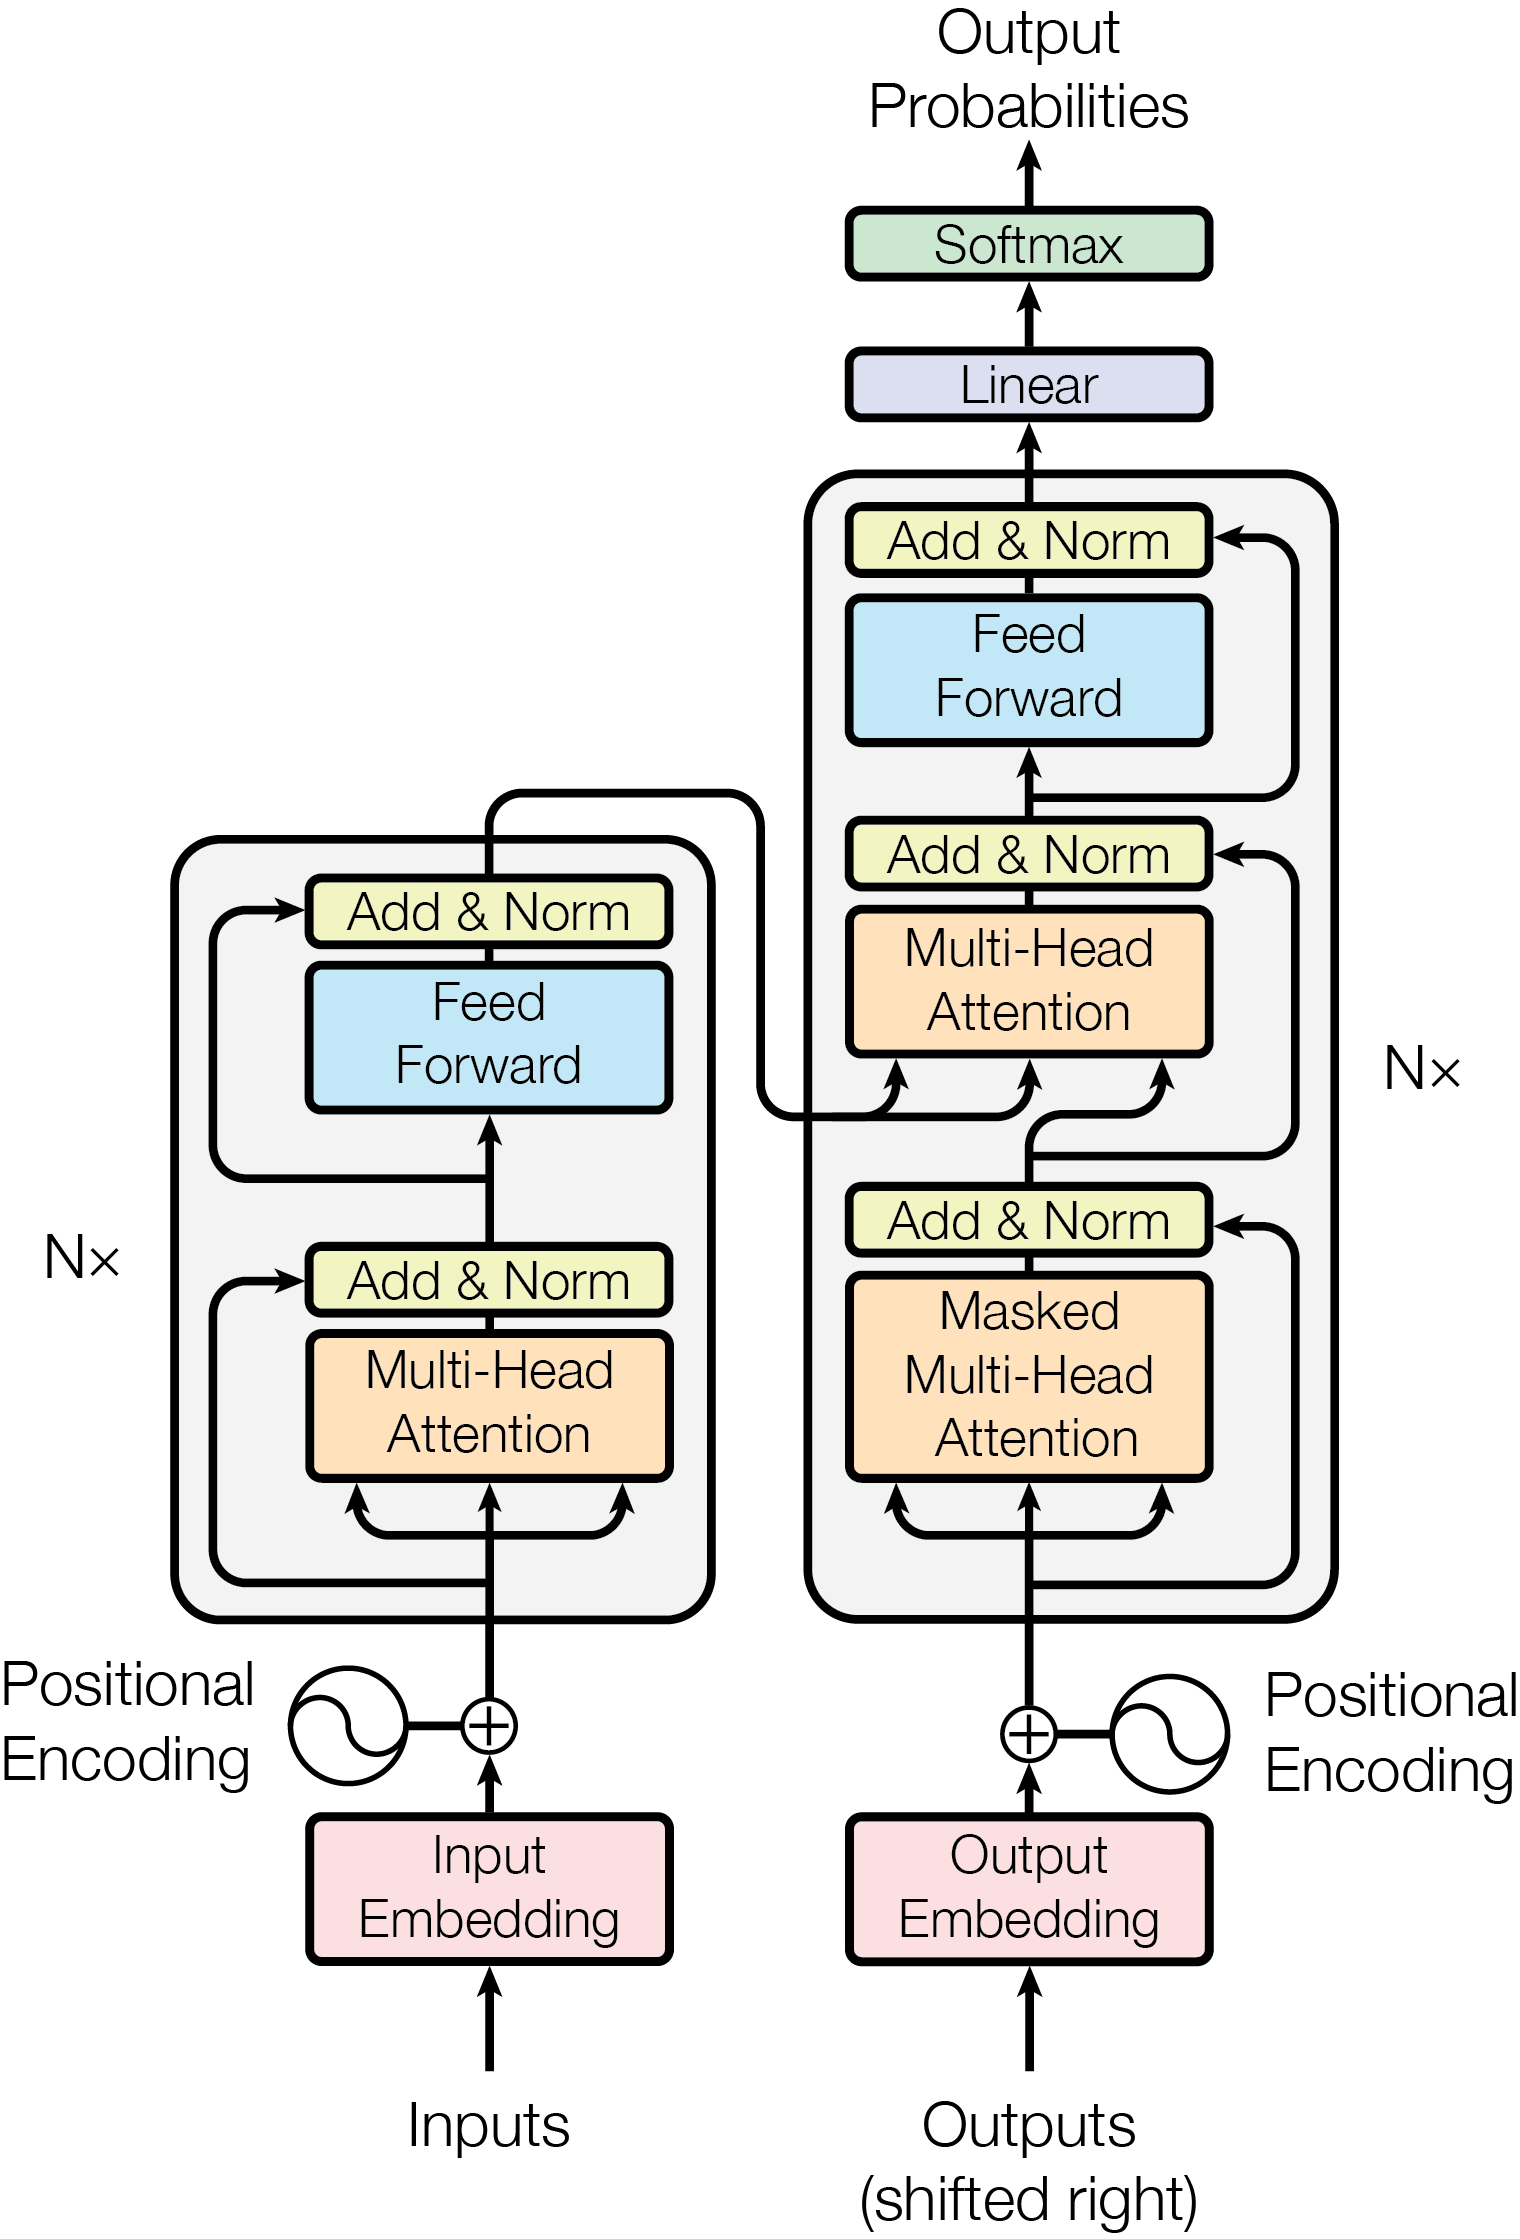

### Создание каузальной маски для декодера (Causal Mask / Target Mask)
---
Она заполняет верхний треугольник матрицы значением минус бесконечность (-inf), чтобы механизм Attention обнулил веса для будущих токенов.

In [ ]:
def generate_square_subsequent_mask(sz, device):
    # Создаем матрицу размера [sz, sz] из единиц, берем верхний треугольник (без главной диагонали)
    mask = (torch.triu(torch.ones((sz, sz), device=device)) == 1).transpose(0, 1)
    # Превращаем в float mask: 0.0 — можно смотреть, -inf — нельзя смотреть
    mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0))
    return mask

### Добавление Позиционного кодирования (Positional Encoding)
---
Поскольку Трансформер обрабатывает все токены параллельно, ему нужно подсказать порядок слов. Вот классическая реализация на синусах и косинусах из статьи Attention Is All You Need

In [ ]:
import torch
import torch.nn as nn
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=1000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        # Формула из статьи: 10000^(2i/d_model)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term) # Четные индексы
        pe[:, 1::2] = torch.cos(position * div_term) # Нечетные индексы
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        # x: [batch_size, seq_len, d_model]
        return x + self.pe[:, :x.size(1)]

### Multi-Head Attention (Многоголовое внимание)

---


Вместо того чтобы делать вычисления для каждой головы отдельно, мы сделаем одну большую проекцию для всех голов сразу, а потом просто «нарежем» тензор (view и transpose).

## Scaled Dot-Product Attention

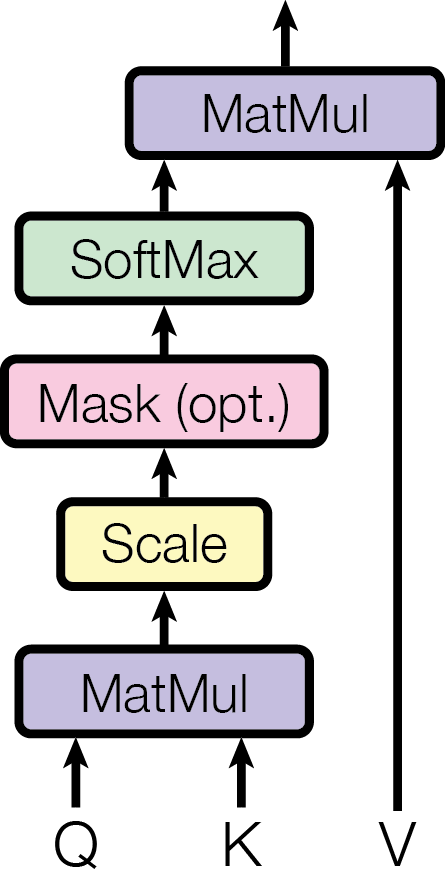

## Multi-Head Attention

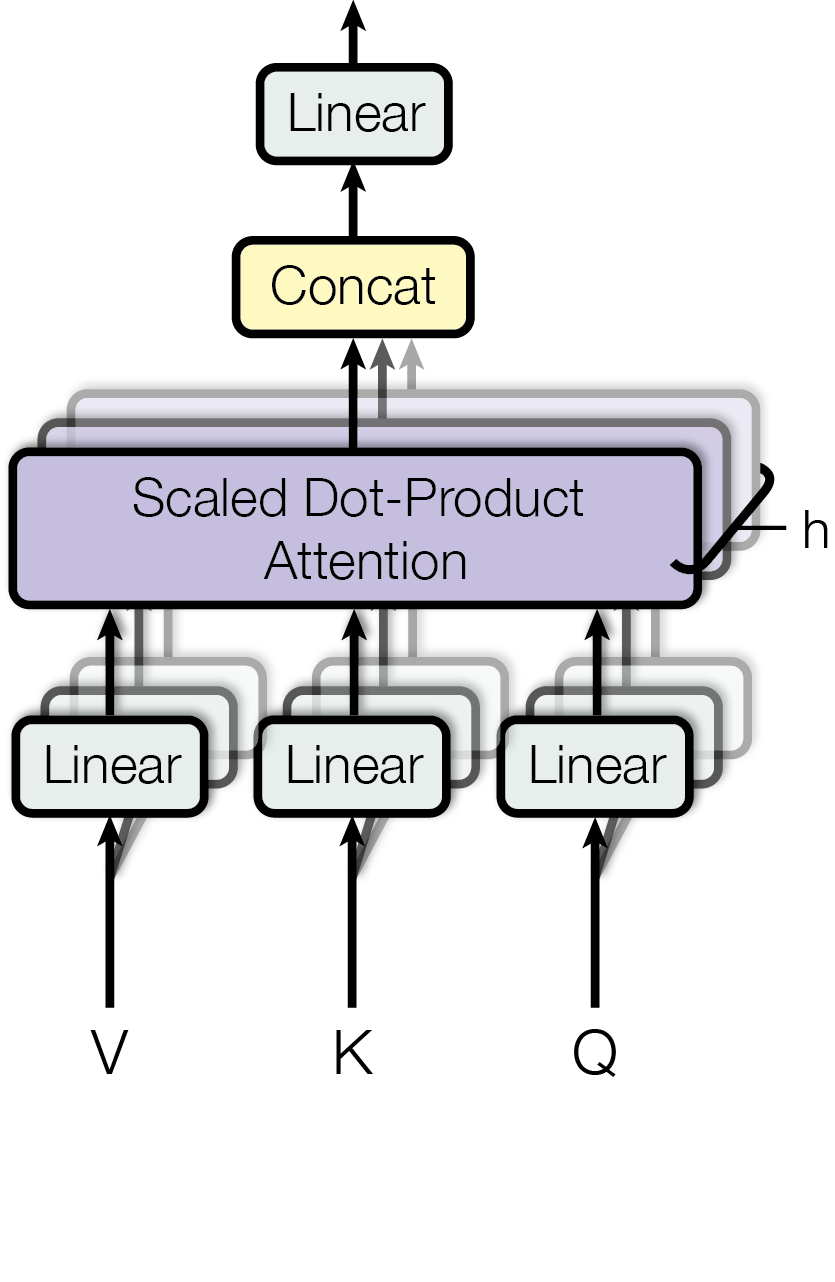

In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, nhead):
        super().__init__()
        self.nhead = nhead
        self.d_k = d_model // nhead

        # Проекции для получения Q, K, V и финального объединения O
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.w_o = nn.Linear(d_model, d_model)

    def forward(self, q, k, v, mask=None, key_padding_mask=None):
        batch_size = q.size(0)

        # Линейный слой + разделение на головы
        # [batch_size, seq_len, d_model] в [batch_size, nhead, seq_len, d_k]
        Q = self.w_q(q).view(batch_size, -1, self.nhead, self.d_k).transpose(1, 2)
        K = self.w_k(k).view(batch_size, -1, self.nhead, self.d_k).transpose(1, 2)
        V = self.w_v(v).view(batch_size, -1, self.nhead, self.d_k).transpose(1, 2)

        # Scaled Dot-Product Attention (Формула из статьи)
        # scores: [batch_size, nhead, seq_len_q, seq_len_k]
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)

        # Применяем каузальную маску (для декодера)
        if mask is not None:
            scores = scores + mask.unsqueeze(0).unsqueeze(1)

        # Применяем padding маску (скрываем [PAD] токены)
        if key_padding_mask is not None:
            scores = scores.masked_fill(key_padding_mask.unsqueeze(1).unsqueeze(2), float('-inf'))

        # Softmax + умножение на V
        attn_weights = torch.softmax(scores, dim=-1)
        context = torch.matmul(attn_weights, V)

        # Склеиваем головы обратно (Concat)
        context = context.transpose(1, 2).contiguous().view(batch_size, -1, self.nhead * self.d_k)
        return self.w_o(context)

### Слои Энкодера и Декодера

---


В оригинальной статье после каждого внимания идет Position-wise Feed-Forward Networks (два линейных слоя с ReLU между ними) и структура Residual + LayerNorm (сложение с исходным входом и нормализация).

In [ ]:
class FeedForward(nn.Module):
    def __init__(self, d_model, dim_feedforward):
        super().__init__()
        self.linear1 = nn.Linear(d_model, dim_feedforward)
        self.relu = nn.ReLU()
        self.linear2 = nn.Linear(dim_feedforward, d_model)

    def forward(self, x):
        return self.linear2(self.relu(self.linear1(x)))

class EncoderLayer(nn.Module):
    def __init__(self, d_model, nhead, dim_feedforward):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, nhead)
        self.ff = FeedForward(d_model, dim_feedforward)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, src, src_padding_mask):
        # Attention + Residual + Norm
        attn_out = self.self_attn(src, src, src, key_padding_mask=src_padding_mask)
        x = self.norm1(src + attn_out)

        # FeedForward + Residual + Norm
        return self.norm2(x + self.ff(x))


class DecoderLayer(nn.Module):
    def __init__(self, d_model, nhead, dim_feedforward):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, nhead)
        self.cross_attn = MultiHeadAttention(d_model, nhead)
        self.ff = FeedForward(d_model, dim_feedforward)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)

    def forward(self, tgt, memory, tgt_mask, tgt_padding_mask, memory_padding_mask):
        # Masked Self-Attention
        attn1 = self.self_attn(tgt, tgt, tgt, mask=tgt_mask, key_padding_mask=tgt_padding_mask)
        x = self.norm1(tgt + attn1)

        # Encoder-Decoder Cross-Attention (Query берем из x, а Key и Value из памяти кодера)
        attn2 = self.cross_attn(x, memory, memory, key_padding_mask=memory_padding_mask)
        x = self.norm2(x + attn2)

        # FeedForward
        return self.norm3(x + self.ff(x))

### Итоговый сборный Трансформер

---


Соединяем стек слоев кодера и декодера вместе.


In [ ]:
class SimpleTransformer(nn.Module):
    def __init__(self, vocab_size, d_model=512, nhead=8, num_layers=6, dim_feedforward=2048, max_len=1000):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoder = PositionalEncoding(d_model, max_len=max_len)

        # Создаем цепочки слоев через nn.ModuleList
        self.encoder_layers = nn.ModuleList([EncoderLayer(d_model, nhead, dim_feedforward) for _ in range(num_layers)])
        self.decoder_layers = nn.ModuleList([DecoderLayer(d_model, nhead, dim_feedforward) for _ in range(num_layers)])

        self.out_linear = nn.Linear(d_model, vocab_size)

    def forward(self, src, tgt, src_padding_mask, tgt_padding_mask, tgt_mask):
        # Проход через Энкодер
        memory = self.pos_encoder(self.embedding(src))
        for layer in self.encoder_layers:
            memory = layer(memory, src_padding_mask)

        # Проход через Декодер
        x = self.pos_encoder(self.embedding(tgt))
        for layer in self.decoder_layers:
            x = layer(x, memory, tgt_mask, tgt_padding_mask, src_padding_mask)

        return self.out_linear(x)

# Обучение модели


---



In [ ]:
vocab_size = tokenizer.get_vocab_size()

# Гиперпараметры
D_MODEL = 512          # Embedding dimension
NHEAD = 8              # Number of attention heads
NUM_LAYERS = 6         # Number of encoder/decoder layers
DIM_FEEDFORWARD = 2048 # Dimension of the feed-forward network

# для экономии памяти
BATCH_SIZE = 4              # вместо 32 (помещается в память)
ACCUMULATION_STEPS = 8      # 4 * 8 = 32 ( batch size)
LEARNING_RATE = 5e-5        # чуть меньше для стабильности
EPOCHS = 3                  # оставляем как было

### Accumulation Steps

---

это трюк, который позволяет использовать большой эффективный batch size, даже если мало видеопамяти. У меня её мало.

Как это работает:

---


Без accumulation:

text
[Батч 1] → forward → backward → обновить веса
[Батч 2] → forward → backward → обновить веса
[Батч 3] → forward → backward → обновить веса

---


С accumulation:

text
[Батч 1] → forward → backward → НЕ обновлять веса (накапливаем градиенты)
[Батч 2] → forward → backward → НЕ обновлять веса (накапливаем градиенты)
[Батч 3] → forward → backward → НЕ обновлять веса (накапливаем градиенты)
...
[Батч 8] → forward → backward → ТЕПЕРЬ обновить веса (градиенты накоплены)

In [ ]:
model = SimpleTransformer(
    vocab_size=vocab_size,
    d_model=D_MODEL,
    nhead=NHEAD,
    num_layers=NUM_LAYERS,
    dim_feedforward=DIM_FEEDFORWARD,
    max_len=1000
)

# Move the model to the GPU if available (you're using a T4 GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(f"Model is running on: {device}")

Model is running on: cuda


In [ ]:
import torch.optim as optim
import gc
import matplotlib.pyplot as plt
import os
from IPython.display import clear_output

# папка для чекпоинтов
CHECKPOINT_DIR = "checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

criterion = nn.CrossEntropyLoss(ignore_index=pad_id)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

train_losses = []
val_losses = []
best_val_loss = float('inf')

In [ ]:
def validate(model, val_dataloader, criterion, device):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for batch in val_dataloader:
            inputs = batch['input_ids'].to(device)
            labels = batch['labels'].to(device)

            tgt_input = labels[:, :-1]
            tgt_out = labels[:, 1:]

            src_padding_mask = (inputs == pad_id).to(device)
            tgt_padding_mask = (tgt_input == pad_id).to(device)
            tgt_mask = generate_square_subsequent_mask(tgt_input.size(1), device)

            logits = model(inputs, tgt_input, src_padding_mask, tgt_padding_mask, tgt_mask)
            loss = criterion(logits.view(-1, logits.size(-1)), tgt_out.contiguous().view(-1))

            total_loss += loss.item()

    model.train()
    return total_loss / len(val_dataloader)

In [ ]:
def save_checkpoint(model, optimizer, epoch, batch_idx, loss, is_best=False):
    checkpoint = {
        'epoch': epoch,
        'batch': batch_idx,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss,
        'best_val_loss': best_val_loss,
        'train_losses': train_losses,
        'val_losses': val_losses,
    }

    torch.save(checkpoint, os.path.join(CHECKPOINT_DIR, "checkpoint_latest.pt"))

    if is_best:
        torch.save(model.state_dict(), os.path.join(CHECKPOINT_DIR, "best_model.pt"))
        print(f"Лучшая модель сохранена! Val Loss: {loss:.4f}")

In [ ]:
def plot_losses(train_losses, val_losses):
    clear_output(wait=True)  # Очищает вывод ячейки

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # График Train Loss
    axes[0].plot(range(1, len(train_losses) + 1), train_losses, 'b-', linewidth=2, label='Train Loss')
    axes[0].set_xlabel('Эпоха')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Train Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # График Validation Loss
    axes[1].plot(range(1, len(val_losses) + 1), val_losses, 'r-', linewidth=2, label='Validation Loss')
    axes[1].set_xlabel('Эпоха')
    axes[1].set_ylabel('Loss')
    axes[1].set_title('Validation Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # Добавляем общий заголовок с лучшим loss
    if val_losses:
        best_val = min(val_losses)
        best_epoch = val_losses.index(best_val) + 1
        fig.suptitle(f'Обучение модели | Лучший Val Loss: {best_val:.4f} (эпоха {best_epoch})', fontsize=14)

    plt.tight_layout()
    plt.show()

In [ ]:
checkpoint_latest_path = os.path.join(CHECKPOINT_DIR, "checkpoint_latest.pt")
start_epoch = 0
start_batch = 0

if os.path.exists(checkpoint_latest_path):
    print("Найден чекпоинт! Восстанавливаю")
    checkpoint = torch.load(checkpoint_latest_path)

    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

    start_epoch = checkpoint['epoch']
    start_batch = checkpoint['batch'] + 1
    best_val_loss = checkpoint.get('best_val_loss', float('inf'))
    train_losses = checkpoint.get('train_losses', [])
    val_losses = checkpoint.get('val_losses', [])

    print(f"Восстановлено: эпоха {start_epoch}, батч {checkpoint['batch']}")

    # Показываем историю обучения
    if train_losses:
        print(f"История: {len(train_losses)} эпох, лучший Val Loss: {min(val_losses):.4f}")
        plot_losses(train_losses, val_losses)
else:
    print("Начинаем обучение с нуля")

Начинаем обучение с нуля


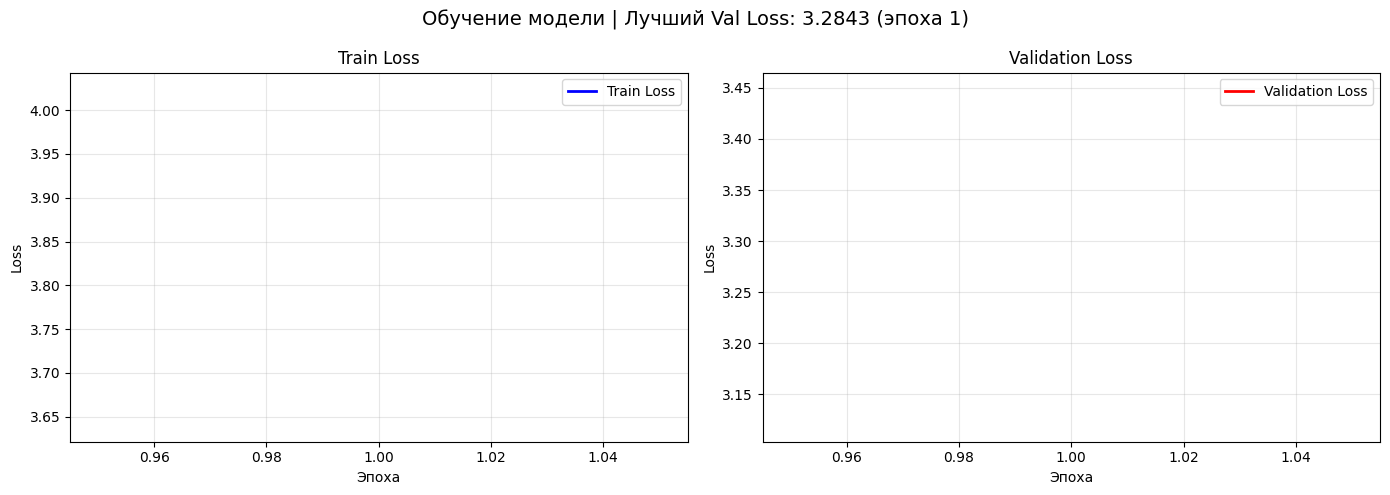

Модель эпохи 1 сохранена как model_epoch_1.pt

Эпоха [2/3], Батч 0, Loss: 2.8262
Эпоха [2/3], Батч 100, Loss: 1.8831
Эпоха [2/3], Батч 200, Loss: 3.1322
Эпоха [2/3], Батч 300, Loss: 4.4876
Эпоха [2/3], Батч 400, Loss: 1.9734
Эпоха [2/3], Батч 500, Loss: 2.6499
Эпоха [2/3], Батч 600, Loss: 2.2761
Эпоха [2/3], Батч 700, Loss: 3.0291
Эпоха [2/3], Батч 800, Loss: 2.3219


KeyboardInterrupt: 

In [ ]:
CHECKPOINT_INTERVAL = 2000

model.train()
for epoch in range(start_epoch, EPOCHS):
    total_loss = 0
    optimizer.zero_grad()

    for batch_idx, batch in enumerate(train_dataloader):
        # Пропускаем уже пройденные батчи
        if epoch == start_epoch and batch_idx < start_batch:
            continue

        # Forward
        inputs = batch['input_ids'].to(device)
        labels = batch['labels'].to(device)

        tgt_input = labels[:, :-1]
        tgt_out = labels[:, 1:]

        src_padding_mask = (inputs == pad_id).to(device)
        tgt_padding_mask = (tgt_input == pad_id).to(device)
        tgt_mask = generate_square_subsequent_mask(tgt_input.size(1), device)

        logits = model(inputs, tgt_input, src_padding_mask, tgt_padding_mask, tgt_mask)
        loss = criterion(logits.view(-1, logits.size(-1)), tgt_out.contiguous().view(-1))

        loss = loss / ACCUMULATION_STEPS
        loss.backward()

        if (batch_idx + 1) % ACCUMULATION_STEPS == 0:
            optimizer.step()
            optimizer.zero_grad()

        total_loss += loss.item() * ACCUMULATION_STEPS

        # Очистка памяти
        if batch_idx % 50 == 0:
            torch.cuda.empty_cache()
            gc.collect()

        # Чекпоинт
        if batch_idx % CHECKPOINT_INTERVAL == 0 and batch_idx > 0:
            real_loss = loss.item() * ACCUMULATION_STEPS
            save_checkpoint(
                model, optimizer, epoch, batch_idx, real_loss,
                is_best=False
            )
            print(f"Чекпоинт сохранен: эпоха {epoch}, батч {batch_idx}, Loss: {real_loss:.4f}")

        # Логи
        if batch_idx % 100 == 0:
            real_loss = loss.item() * ACCUMULATION_STEPS
            print(f"Эпоха [{epoch+1}/{EPOCHS}], Батч {batch_idx}, Loss: {real_loss:.4f}")

    # итог эпохи
    avg_train_loss = total_loss / len(train_dataloader)
    train_losses.append(avg_train_loss)

    # валидация
    print("\nВыполняется валидация")
    avg_val_loss = validate(model, val_dataloader, criterion, device)
    val_losses.append(avg_val_loss)

    # результаты
    print(f"Итог Эпохи {epoch+1}:")
    print(f"   Train Loss: {avg_train_loss:.4f}")
    print(f"   Val Loss:   {avg_val_loss:.4f}")


    # сохраняем лучшую
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        save_checkpoint(
            model, optimizer, epoch, batch_idx, avg_val_loss,
            is_best=True
        )

    plot_losses(train_losses, val_losses)

    torch.save(model.state_dict(), os.path.join(CHECKPOINT_DIR, f"model_epoch_{epoch+1}.pt"))
    print(f"Модель эпохи {epoch+1} сохранена как model_epoch_{epoch+1}.pt\n")

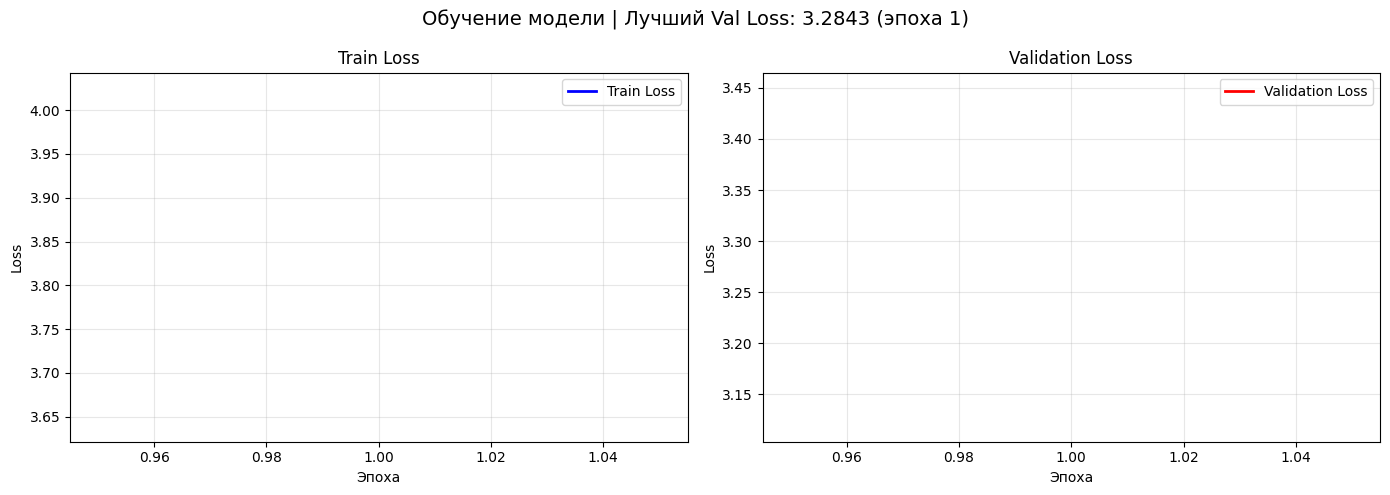


Обучение завершено!
   Лучший Val Loss: 3.2843


In [ ]:
plot_losses(train_losses, val_losses)

print(f"\nОбучение завершено!")
print(f"   Лучший Val Loss: {best_val_loss:.4f}")

# Инференс

---



In [ ]:
import torch
import torch.nn.functional as F


def load_model(model_path="checkpoints/best_model.pt"):
    model = SimpleTransformer(
        vocab_size=vocab_size,
        d_model=D_MODEL,
        nhead=NHEAD,
        num_layers=NUM_LAYERS,
        dim_feedforward=DIM_FEEDFORWARD,
        max_len=1000
    ).to(device)

    model.load_state_dict(torch.load(model_path))
    model.eval()
    print(f"Модель загружена из {model_path}")
    return model

In [ ]:
def translate(model, text, max_len=100):
    model.eval()

    # Токенизируем входной текст
    ru_encoded = tokenizer.encode(text).ids

    # Обрезаем, если слишком длинный
    if len(ru_encoded) > 500:
        ru_encoded = ru_encoded[:500]

    # Добавляем [EOS]
    src_tokens = ru_encoded + [eos_id]
    src_tensor = torch.tensor([src_tokens], dtype=torch.long).to(device)

    # Создаем маску для энкодера
    src_padding_mask = (src_tensor == pad_id).to(device)

    # Прогоняем через энкодер
    with torch.no_grad():
        memory = model.pos_encoder(model.embedding(src_tensor))
        for layer in model.encoder_layers:
            memory = layer(memory, src_padding_mask)

    # Генерация перевода (пошагово)
    tgt_tokens = [bos_id]  # начинаем с [BOS]

    for _ in range(max_len):
        tgt_tensor = torch.tensor([tgt_tokens], dtype=torch.long).to(device)
        tgt_mask = generate_square_subsequent_mask(len(tgt_tokens), device)
        tgt_padding_mask = (tgt_tensor == pad_id).to(device)

        with torch.no_grad():
            x = model.pos_encoder(model.embedding(tgt_tensor))
            for layer in model.decoder_layers:
                x = layer(x, memory, tgt_mask, tgt_padding_mask, src_padding_mask)

            logits = model.out_linear(x[:, -1, :])

            # Берем токен с максимальной вероятностью (greedy)
            next_token = torch.argmax(logits, dim=-1).item()

        # Если сгенерирован [EOS] — останавливаемся
        if next_token == eos_id:
            break

        tgt_tokens.append(next_token)

    # Декодируем токены в текст
    translated_text = tokenizer.decode(tgt_tokens[1:])
    return translated_text

In [ ]:
def translate_examples(model, examples):
    print("примеры перевода")
    print()

    for i, (ru_text, en_expected) in enumerate(examples, 1):
        print(f"Пример {i}:")
        print(f"  RU: {ru_text}")
        print(f"  EN (ожидаемый): {en_expected}")

        translated = translate(model, ru_text)
        print(f"  EN (перевод):   {translated}")

In [ ]:
def interactive_translate(model):
    print()
    print("интерактивный перевод")
    print()
    print("Введите текст на русском (или 'exit' для выхода):\n")

    while True:
        text = input("RU: ").strip()
        if text.lower() in ['exit', 'quit', 'выход']:
            print("До свидания!")
            break

        if not text:
            continue

        translated = translate(model, text)
        print(f"EN: {translated}\n")

In [ ]:
# Загружаем лучшую модель
model = load_model("checkpoints/best_model.pt")

# Примеры для теста
test_examples = [
    ("Привет, как дела?", "Hello, how are you?"),
    ("Я люблю машинное обучение", "I love machine learning"),
    ("Сегодня хорошая погода", "Today is good weather"),
    ("Это очень интересная задача", "This is a very interesting task"),
    ("Модель Transformer работает хорошо", "The Transformer model works well"),
]

# Переводим примеры
translate_examples(model, test_examples)

# Интерактивный режим (раскомментируйте, если хотите)
# interactive_translate(model)

Модель загружена из checkpoints/best_model.pt
примеры перевода

Пример 1:
  RU: Привет, как дела?
  EN (ожидаемый): Hello, how are you?
  EN (перевод):   Hey , how are you ?
Пример 2:
  RU: Я люблю машинное обучение
  EN (ожидаемый): I love machine learning
  EN (перевод):   I love a free school
Пример 3:
  RU: Сегодня хорошая погода
  EN (ожидаемый): Today is good weather
  EN (перевод):   Tonight today ,
Пример 4:
  RU: Это очень интересная задача
  EN (ожидаемый): This is a very interesting task
  EN (перевод):   It ' s a very interesting task
Пример 5:
  RU: Модель Transformer работает хорошо
  EN (ожидаемый): The Transformer model works well
  EN (перевод):   Model - The - school works


# Оценка модели

---



In [ ]:
!pip install sacrebleu torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 39.7 MB/s eta 0:00:00


In [ ]:
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')

!pip install sacrebleu

import sacrebleu
from nltk.translate.meteor_score import meteor_score

def calculate_ter(hypotheses, references):
    total_edits = 0
    total_words = 0

    for hyp, ref in zip(hypotheses, references):
        hyp_words = hyp.split()
        ref_words = ref.split()

        # Простейшая реализация TER через расстояние Левенштейна на уровне слов
        n = len(hyp_words)
        m = len(ref_words)

        dp = [[0] * (m + 1) for _ in range(n + 1)]
        for i in range(n + 1):
            dp[i][0] = i
        for j in range(m + 1):
            dp[0][j] = j

        for i in range(1, n + 1):
            for j in range(1, m + 1):
                if hyp_words[i-1] == ref_words[j-1]:
                    dp[i][j] = dp[i-1][j-1]
                else:
                    dp[i][j] = 1 + min(dp[i-1][j], dp[i][j-1], dp[i-1][j-1])

        total_edits += dp[n][m]
        total_words += m

    return total_edits / total_words if total_words > 0 else 0

def calculate_metrics(model, dataloader, max_samples=100):
    model.eval()

    references = []
    hypotheses = []

    with torch.no_grad():
        for batch_idx, batch in enumerate(dataloader):
            if batch_idx >= max_samples:
                break

            src = batch['input_ids'][0:1].to(device)
            tgt = batch['labels'][0:1].to(device)

            memory = model.pos_encoder(model.embedding(src))
            for layer in model.encoder_layers:
                memory = layer(memory, (src == pad_id).to(device))

            tgt_tokens = [bos_id]

            for _ in range(100):
                tgt_tensor = torch.tensor([tgt_tokens], dtype=torch.long).to(device)
                tgt_mask = generate_square_subsequent_mask(len(tgt_tokens), device)
                tgt_padding_mask = (tgt_tensor == pad_id).to(device)
                src_padding_mask = (src == pad_id).to(device)

                x = model.pos_encoder(model.embedding(tgt_tensor))
                for layer in model.decoder_layers:
                    x = layer(x, memory, tgt_mask, tgt_padding_mask, src_padding_mask)

                logits = model.out_linear(x[:, -1, :])
                next_token = torch.argmax(logits, dim=-1).item()

                if next_token == eos_id:
                    break
                tgt_tokens.append(next_token)

            ref_text = tokenizer.decode(tgt[0].tolist())
            ref_text = ref_text.replace('[BOS]', '').replace('[EOS]', '').replace('[PAD]', '').strip()

            hyp_text = tokenizer.decode(tgt_tokens[1:])

            references.append(ref_text)
            hypotheses.append(hyp_text)

    bleu = sacrebleu.corpus_bleu(hypotheses, [[ref] for ref in references])

    meteor_scores = []
    for hyp, ref in zip(hypotheses, references):
        score = meteor_score([ref.split()], hyp.split())
        meteor_scores.append(score)
    meteor = sum(meteor_scores) / len(meteor_scores)

    ter = calculate_ter(hypotheses, references)

    print(f"BLEU: {bleu.score:.2f}")
    print(f"METEOR: {meteor:.4f}")
    print(f"TER: {ter:.4f}")

    return bleu.score, meteor, ter

metrics = calculate_metrics(model, val_dataloader, max_samples=100)

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


BLEU: 20.01
METEOR: 0.3927
TER: 1.0747


In [ ]:
import pandas as pd

results = {
    'Метрика': ['BLEU', 'METEOR', 'TER'],
    'Значение': [metrics[0], metrics[1], metrics[2]]
}
df = pd.DataFrame(results)
print(df.to_string(index=False))

Метрика  Значение
   BLEU 20.008008
 METEOR  0.392723
    TER  1.074706


In [ ]:
def analyze_errors(model, dataloader, num_examples=10):
    model.eval()

    errors = []

    with torch.no_grad():
        for batch_idx, batch in enumerate(dataloader):
            if batch_idx >= num_examples:
                break

            src = batch['input_ids'][0:1].to(device)
            tgt = batch['labels'][0:1].to(device)

            src_text = tokenizer.decode(src[0].tolist())
            src_text = src_text.replace('[BOS]', '').replace('[EOS]', '').replace('[PAD]', '').strip()

            ref_text = tokenizer.decode(tgt[0].tolist())
            ref_text = ref_text.replace('[BOS]', '').replace('[EOS]', '').replace('[PAD]', '').strip()

            memory = model.pos_encoder(model.embedding(src))
            for layer in model.encoder_layers:
                memory = layer(memory, (src == pad_id).to(device))

            tgt_tokens = [bos_id]
            for _ in range(100):
                tgt_tensor = torch.tensor([tgt_tokens], dtype=torch.long).to(device)
                tgt_mask = generate_square_subsequent_mask(len(tgt_tokens), device)
                tgt_padding_mask = (tgt_tensor == pad_id).to(device)
                src_padding_mask = (src == pad_id).to(device)

                x = model.pos_encoder(model.embedding(tgt_tensor))
                for layer in model.decoder_layers:
                    x = layer(x, memory, tgt_mask, tgt_padding_mask, src_padding_mask)

                logits = model.out_linear(x[:, -1, :])
                next_token = torch.argmax(logits, dim=-1).item()

                if next_token == eos_id:
                    break
                tgt_tokens.append(next_token)

            hyp_text = tokenizer.decode(tgt_tokens[1:])

            errors.append({
                'src': src_text,
                'ref': ref_text,
                'hyp': hyp_text
            })

    for i, error in enumerate(errors, 1):
        print(f"\nПример {i}:")
        print(f"  Исходник: {error['src']}")
        print(f"  Референс: {error['ref']}")
        print(f"  Перевод:  {error['hyp']}")

    return errors

analyze_errors(model, val_dataloader, num_examples=10)


Пример 1:
  Исходник: Было так холодно на улице , вы просто не представля ете .
  Референс: It ' s so cold out there , you ' ve no idea .
  Перевод:  It was so cold , you just don ' t have to do it .

Пример 2:
  Исходник: Я всё знаю , мистер Уол кер .
  Референс: Nothing gets by me , Mr . Wal ker .
  Перевод:  I know everything , Mr . Wal ker .

Пример 3:
  Исходник: Есть ли шанс , что все это просто обру шится ?
  Референс: Isn ' t there a chance this lot ' s just gonna collapse ?
  Перевод:  Is there anything that ' s just a joke ?

Пример 4:
  Исходник: 34 И зна чали й 25 гер . ( 00 : 06 : 31 )
  Референс: 3 Im mer se us 10 ( 00 : 06 : 32 )
  Перевод:  34 25 H ( 00 : 06 : 31 )

Пример 5:
  Исходник: Но два учени ка - это не достаточно , чтобы держать открытой школу .
  Референс: Two students are not enough to sustain a school .
  Перевод:  But two - is not enough enough to keep the school school .

Пример 6:
  Исходник: Они знали , о деньгах , и они знали точную сумму .
  Референс

[{'src': 'Было так холодно на улице , вы просто не представля ете .',
  'ref': "It ' s so cold out there , you ' ve no idea .",
  'hyp': "It was so cold , you just don ' t have to do it ."},
 {'src': 'Я всё знаю , мистер Уол кер .',
  'ref': 'Nothing gets by me , Mr . Wal ker .',
  'hyp': 'I know everything , Mr . Wal ker .'},
 {'src': 'Есть ли шанс , что все это просто обру шится ?',
  'ref': "Isn ' t there a chance this lot ' s just gonna collapse ?",
  'hyp': "Is there anything that ' s just a joke ?"},
 {'src': '34 И зна чали й 25 гер . ( 00 : 06 : 31 )',
  'ref': '3 Im mer se us 10 ( 00 : 06 : 32 )',
  'hyp': '34 25 H ( 00 : 06 : 31 )'},
 {'src': 'Но два учени ка - это не достаточно , чтобы держать открытой школу .',
  'ref': 'Two students are not enough to sustain a school .',
  'hyp': 'But two - is not enough enough to keep the school school .'},
 {'src': 'Они знали , о деньгах , и они знали точную сумму .',
  'ref': 'They knew about the money and they knew the exact amount .',
